# Simulated  Profile 2

 - Mateusz Tabaszewski
 - Bartłomiej Pukacki
 - Adam Mielniczuk
 - Krzysztof Weber

## Description

This profile represents an individual who is strongly motivated by breaking their own records, seeing their own success and competing with others, however, is less likely to respond when prompted if tired or stressed.

To reflect this we implemented the following changes:

 1. Inside __init__()
  - Added variables representing the personal best value, current streak and bonus motivation when outperforming themselves
  - Added variables representing bonus from competing with peers and benchmark of peer abilities

 2. Inside update_after_day()
  - Updates the streak variables at the end of the day
  - Updates peer performance

 3. Inside get_motivation()
  - Introduced the streak bonus for maintaining consistent performance for a number of days
  - Introduced a personal best motivation bonus when breaking or nearing the breaking of personal records
  - Introduced a bonus for outperforming peers

 4. Adjustments to get_ability()
 - Changed not_tired_of_repeating_the_activity to -2: Since the patient is heavily influenced by being tired
 - Changed cognitive_load to -1: Since the patient is influenced by stress and cognitive load

In [1]:
import pandas as pd
import numpy as np
import os

from textwrap import wrap
from matplotlib import pyplot as plt
from stable_baselines3 import PPO, A2C, DQN
from sklearn.ensemble import RandomForestClassifier

In [2]:
from environment.profile_2 import Profile2 as Patient

In [3]:
updated_every_day = 24 
week = 7 * updated_every_day

In [4]:
eight_weeks = week * 8
five_weeks = week * 5

In [5]:
# Basic stable condition
condition = 'stable'
habituation = False
time_preference_update_step = 9999999999999999 #very high e.g. 9999999999 to make it out of the intervention time...effectively no preference shift

# Other options (not considered in the AIBI project):
# condition = 'habituated'
# habituation=True
# time_preference_update_step= 9999999999999999 

# condition = 'changed_preference'
# habituation=False
# time_preference_update_step= five_weeks

# condition = 'habituated_changed_preference'
# habituation=True
# time_preference_update_step= five_weeks

In [6]:
# 500 runs in the paper
runs = 500

In [7]:
results_directory = 'results'
if not os.path.exists(results_directory):
    os.makedirs(results_directory)

# No interverntion

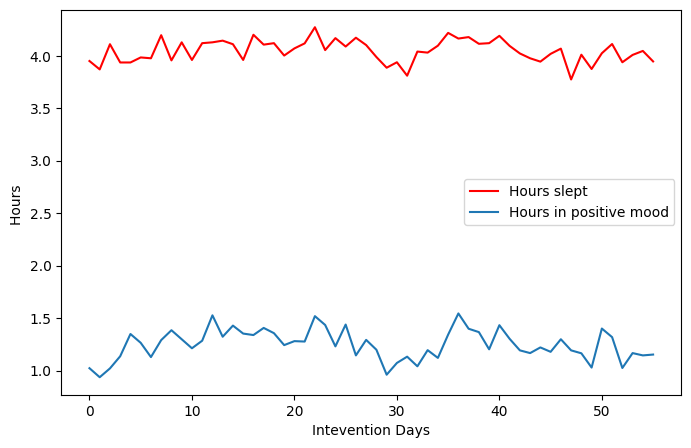

In [8]:
sleep_list = []
positive_list = []

for run in range(0, runs):
    
    env1 = Patient(behavior_threshold=20, habituation=habituation, time_preference_update_step=time_preference_update_step)
    action = 0
    for i in  range(eight_weeks):
        
        observation, reward, terminated, truncated, info = env1.step(action)
        action = 0
    
    
    sleep_list.append(env1.h_slept)
    positive_list.append(env1.h_positive)

fig = plt.figure( figsize=(8, 5))
plt.plot(np.nanmean(sleep_list, axis=0), label='Hours slept', color ='r')
plt.plot(np.mean(positive_list, axis=0), label='Hours in positive mood')
plt.ylabel('Hours ')
plt.xlabel('Intevention Days')
plt.legend()
plt.show()

# Intervention

In [9]:
def intervention(method, runs, name, condition):
    rr_random_list = []
    not_random_list = []
    sleep_list = []
    positive_list = []
    performed = 0
    for run in range(0, runs):

        env1 = Patient(behavior_threshold=20, habituation=habituation, time_preference_update_step=time_preference_update_step)
        env1 = method(env1)
        if sum(env1.num_performed):
            performed += 1
        df = pd.DataFrame()
        df['response_ratio'] = env1.rr
        df['activity performed'] = env1.num_performed
        df['notifications'] = env1.num_notified
        df['sleep'] = env1.h_slept
        df['positive'] = env1.h_positive
        df['non_stationary'] = env1.h_nonstationary
        
        df.to_csv("{0}/patient1_{1}_{2}_run{3}.csv".format(results_directory, condition, name, run))
        rr_random_list.append(df.response_ratio)
        not_random_list.append(df.notifications)
        sleep_list.append(df.sleep)
        positive_list.append(df.positive)

    
    print("This figures include runs in which no prompt resulted in the activity being performed")
    print("{0} out of {1} resulted in activity being performed ".format(performed, runs))
    fig = plt.figure( figsize=(8, 5))
    plt.plot(np.nanmean(np.array(sleep_list), axis=0), label='Hours slept', color ='r')
    plt.plot(np.mean(positive_list, axis=0), label='Hours in positive mood')
    plt.ylabel('Hours ')
    plt.xlabel('Intevention Days')
    plt.legend()
    plt.show()

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=False, figsize=(10, 8))
    ax1.plot(np.nanmean(rr_random_list, axis=0), label='response ratio', color ='r')
    ax2.plot(np.nanmean(not_random_list, axis=0), label='num of notifications')
    ax2.set_xlabel('Intervention days')
    ax2.set_ylabel('No. of notifications')
    ax1.set_ylabel('Response ratio')
    plt.show()
    return sleep_list, positive_list, rr_random_list, not_random_list

## Heuristic

Notify every hour except in night and when the patient is alseep

In [10]:
def always_notify(env1, intervention_legth=eight_weeks):
    
    action = 0
    for i in  range(intervention_legth):
        
        observation, reward, terminated, truncated, info = env1.step(action)
        if observation[9] == 3 or observation[3] == 1: # do not prompt at night (index 9) or when sleeping (index 3)
            action = 0
        else:
            action = 1
            
    return env1

This figures include runs in which no prompt resulted in the activity being performed
119 out of 500 resulted in activity being performed 


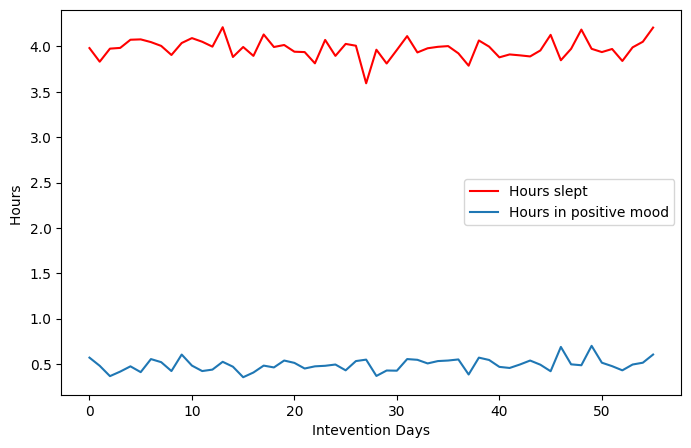

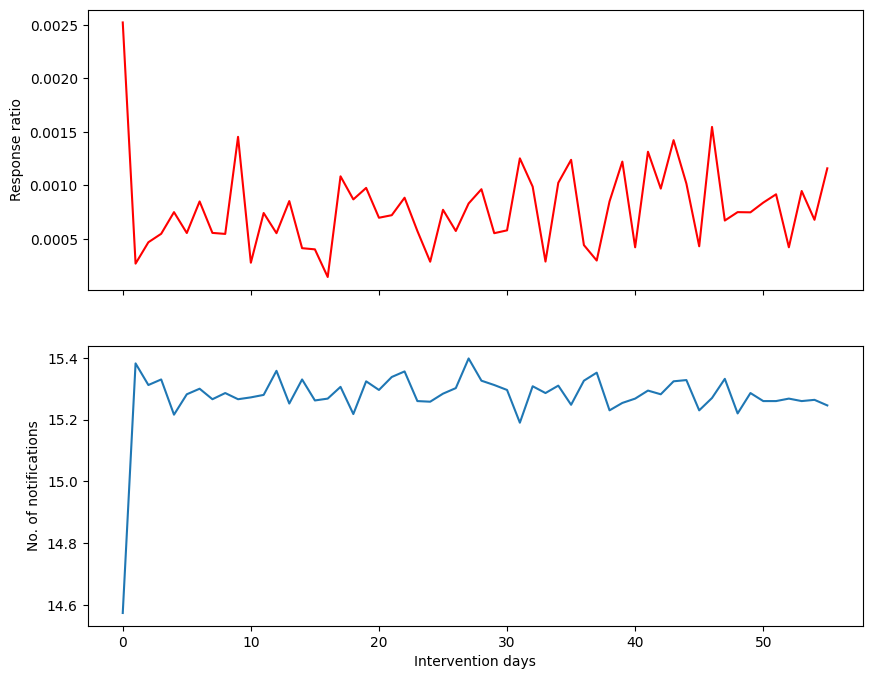

In [11]:
sleep_listh, positive_listh, rr_h_list, not_h_list = intervention(always_notify, runs, 'h', condition)

## Random 
Randomly sample during the day skip the nights

In [12]:
def random_notification(env1, intervention_legth=eight_weeks):
    
    action = 0
    for i in  range(intervention_legth):
        
        observation, reward, terminated, truncated, info = env1.step(action)
        if observation[9] ==3:
            action = 0
        else:
            action = env1.action_space.sample()
            
    return env1

This figures include runs in which no prompt resulted in the activity being performed
216 out of 500 resulted in activity being performed 


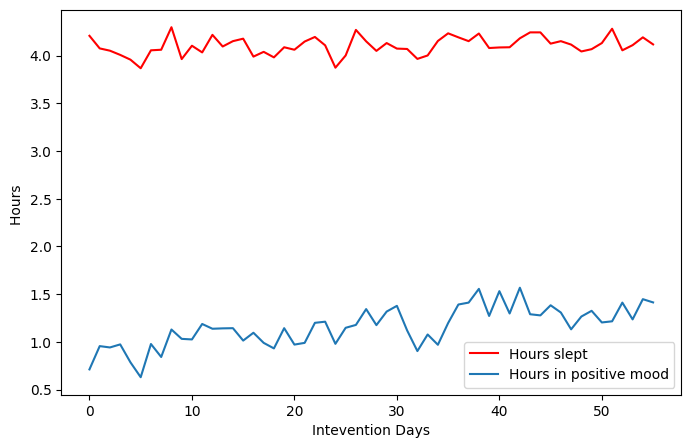

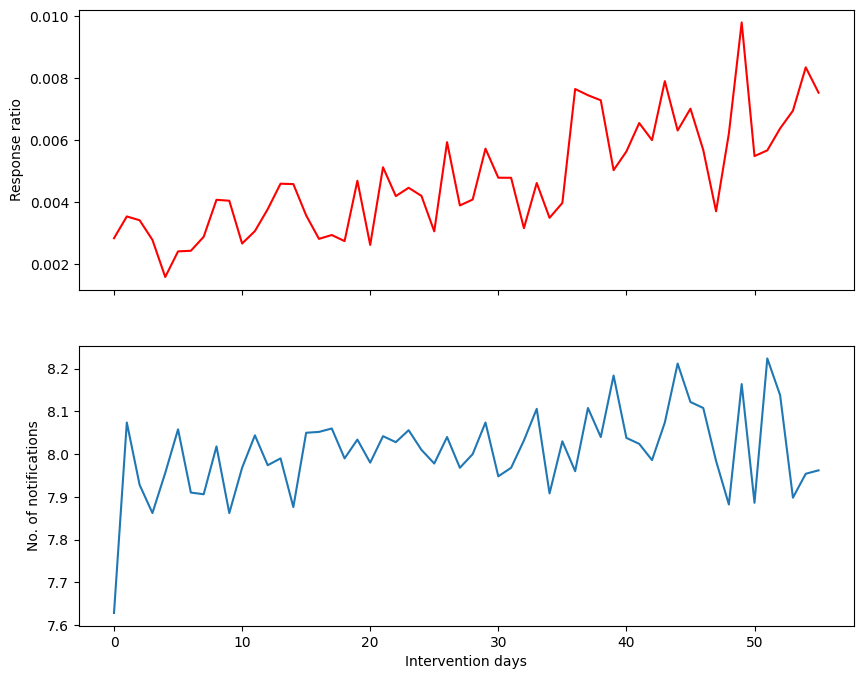

CPU times: user 7.9 s, sys: 40.9 ms, total: 7.94 s
Wall time: 7.94 s


In [13]:
%time _ = intervention(random_notification, runs, 'random', condition)

In [14]:
def get_rr_and_notification(name, runs, condition):
    
    rr, noti = [],[]
    failed = 0
    for run in range(runs):
        df = pd.read_csv("{0}/patient1_{1}_{2}_run{3}.csv".format(results_directory,condition, name, run))
        a_performed = sum(df['activity performed'].values)
        if a_performed > 0: # activity performed at least once in the course of the intervention
            rr.append(df.response_ratio)
            noti.append(df.notifications)
        else:
            failed = failed +1 
    print(" {0} out of {1} runs had no activity performed throughout the full intervention.".format(failed, runs))
    return rr, noti, failed

In [15]:
rr_random_list, not_random_list, fppo = get_rr_and_notification('random', runs, condition)

 284 out of 500 runs had no activity performed throughout the full intervention.


## Supervised Learning

### Static model

In [16]:
def supervised_after_three_weeks(env1):
    
    three_weeks = 24 * 7 * 3
    env1 = always_notify(env1, intervention_legth=three_weeks)
    clf = RandomForestClassifier(class_weight='balanced')
    clf.fit(env1.observation_list, env1.activity_performed)
    remaining_time = eight_weeks - three_weeks
    observation = env1._get_current_state()
    for i in range(remaining_time):
        # applying supervised model
        action = clf.predict(np.array([observation]))[0]
        observation, reward, terminated, truncated, info = env1.step(action)
        
    return env1

This figures include runs in which no prompt resulted in the activity being performed
81 out of 500 resulted in activity being performed 


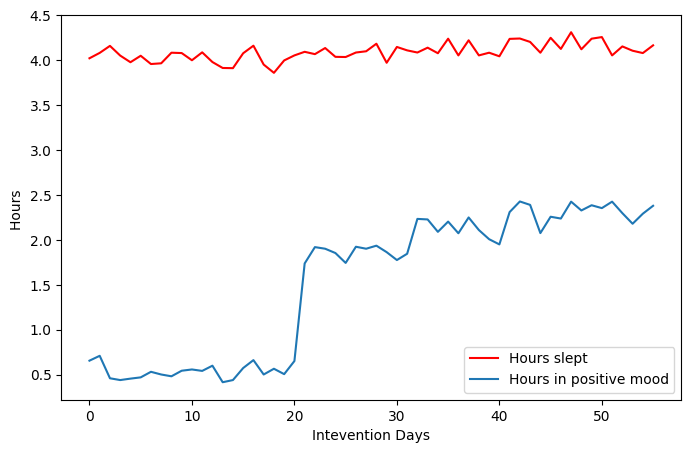

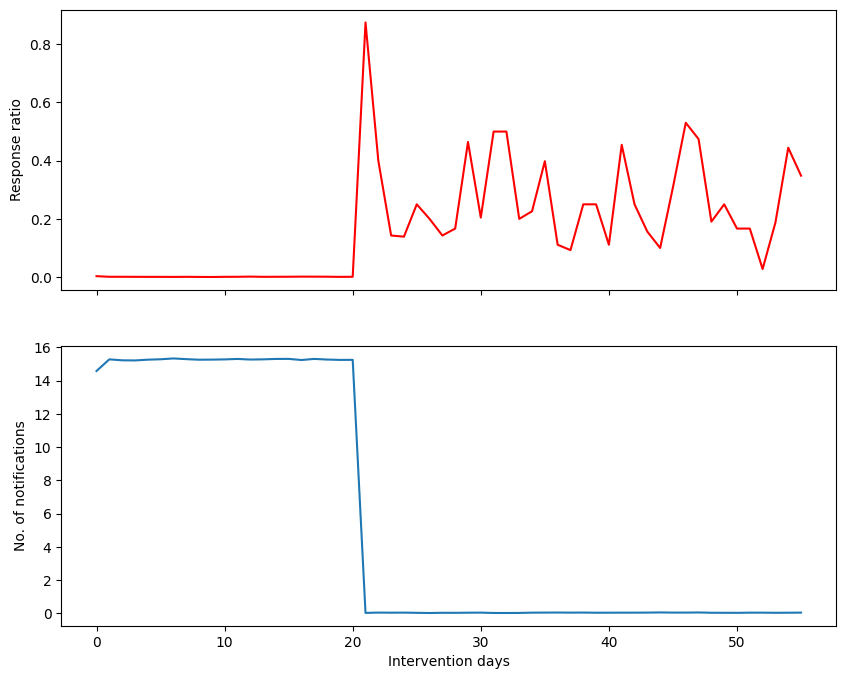

CPU times: user 20min 33s, sys: 31.9 s, total: 21min 5s
Wall time: 19min 54s


In [17]:
%time _ = intervention(supervised_after_three_weeks,runs , 'static_sup3', condition)

### Adaptive model 

In [18]:
def supervised_adaptive_after_three_weeks(env1):
    
    three_weeks = 24*7*3
    env1 = always_notify(env1, intervention_legth=three_weeks)
    clf = RandomForestClassifier(class_weight='balanced')
    clf.fit(env1.observation_list, env1.activity_performed)
    remaining_time = eight_weeks - three_weeks
    observation = env1._get_current_state()
    samples = len(env1.observation_list)
    for i in range(remaining_time):
        # applying supervised model
        action = clf.predict(np.array([observation]))[0]
        observation, reward, terminated, truncated, info = env1.step(action)
        if len(env1.observation_list)> samples: # retrain when new samples are provided
            clf = RandomForestClassifier(class_weight='balanced')
            clf.fit(env1.observation_list, env1.activity_performed)
            samples = len(env1.observation_list)
            
        
    return env1

This figures include runs in which no prompt resulted in the activity being performed
82 out of 500 resulted in activity being performed 


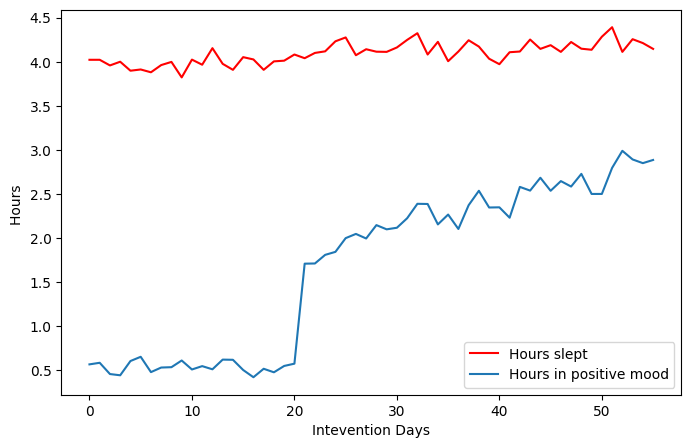

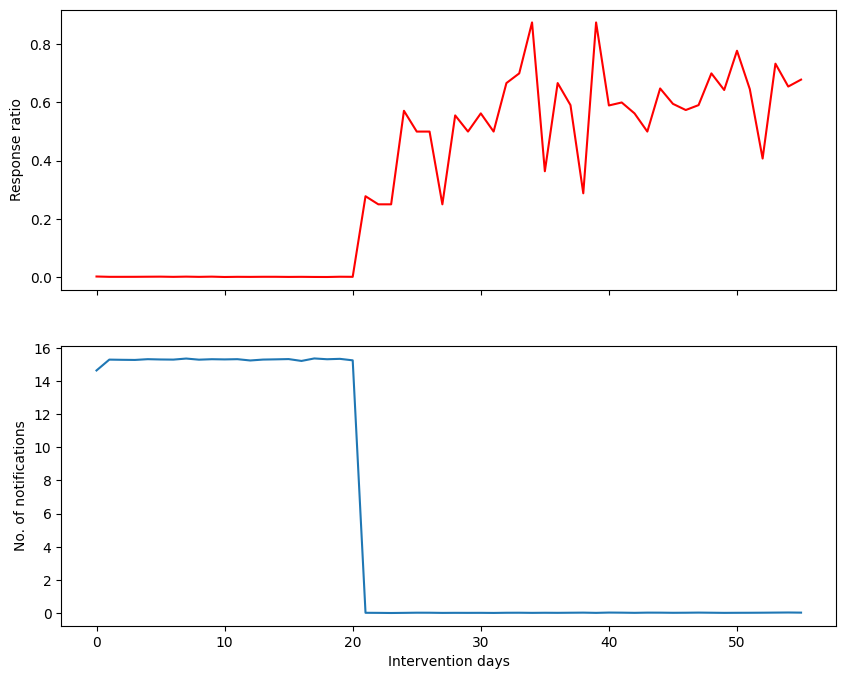

CPU times: user 20min 42s, sys: 29 s, total: 21min 11s
Wall time: 20min 5s


In [19]:
%time _ = intervention(supervised_adaptive_after_three_weeks, runs, 'adaptive_sup3', condition)

### How many times supervised training faild?

In [20]:
rr_rf3_list, not_rf3_list, frf3 = get_rr_and_notification('static_sup3', runs, condition)

 419 out of 500 runs had no activity performed throughout the full intervention.


In [21]:
rr_rf3a_list, not_rf3a_list, frf3a = get_rr_and_notification('adaptive_sup3', runs, condition)

 418 out of 500 runs had no activity performed throughout the full intervention.


## Deep Q Network

In [22]:
def dqn(env1):
    model = DQN("MlpPolicy", env1, verbose=0, learning_starts=updated_every_day)
    model.learn(total_timesteps=eight_weeks)
    return env1

This figures include runs in which no prompt resulted in the activity being performed
234 out of 500 resulted in activity being performed 


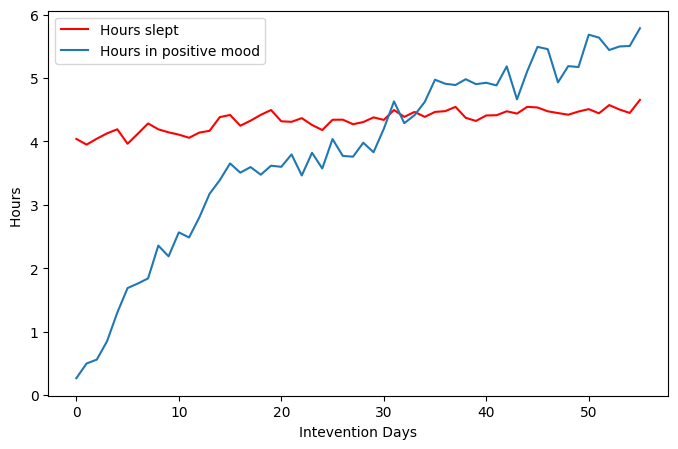

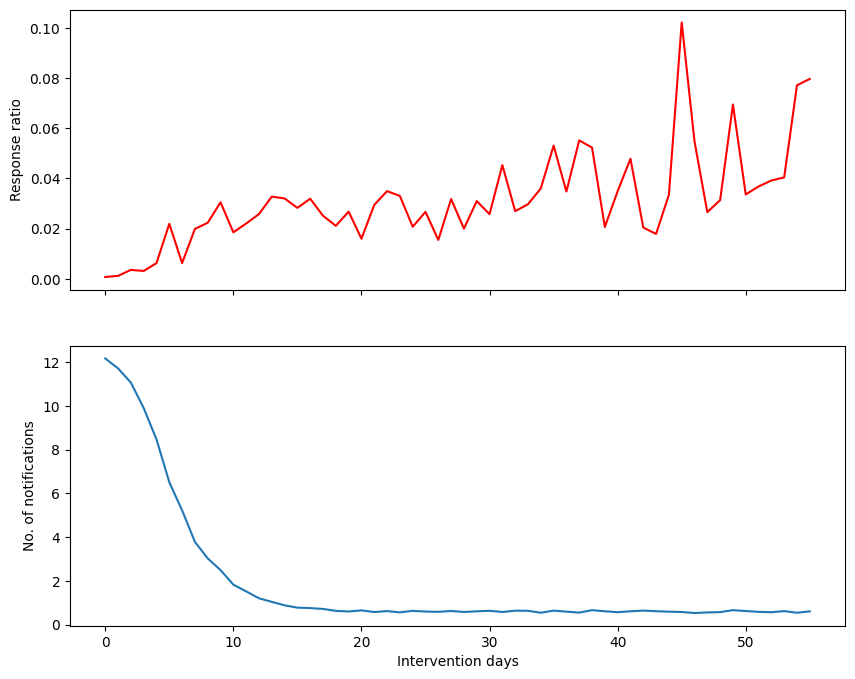

CPU times: user 8min 43s, sys: 1.49 s, total: 8min 45s
Wall time: 8min 48s


In [23]:
%time _= intervention(dqn, runs, 'dqn', condition)

In [24]:
rr_dqn_list, not_dqn_list, fdqn = get_rr_and_notification('dqn', runs, condition)

 266 out of 500 runs had no activity performed throughout the full intervention.


## Proximal Policy Optimisation

In [25]:
def ppo(env1):
    model = PPO("MlpPolicy", env1, verbose=0, n_steps=updated_every_day, batch_size=updated_every_day, device="cpu")
    model.learn(total_timesteps=eight_weeks)
    return env1

This figures include runs in which no prompt resulted in the activity being performed
217 out of 500 resulted in activity being performed 


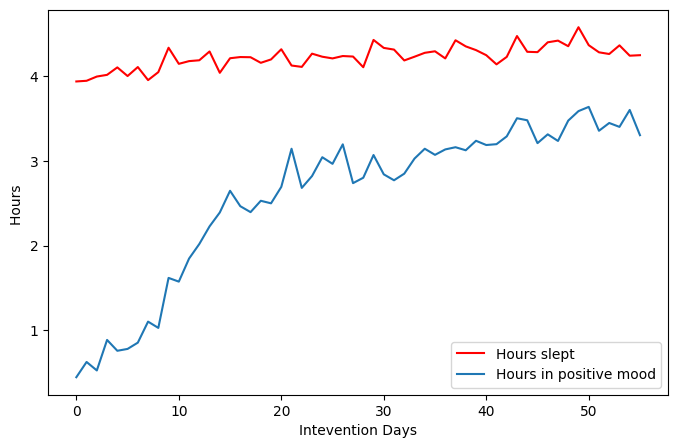

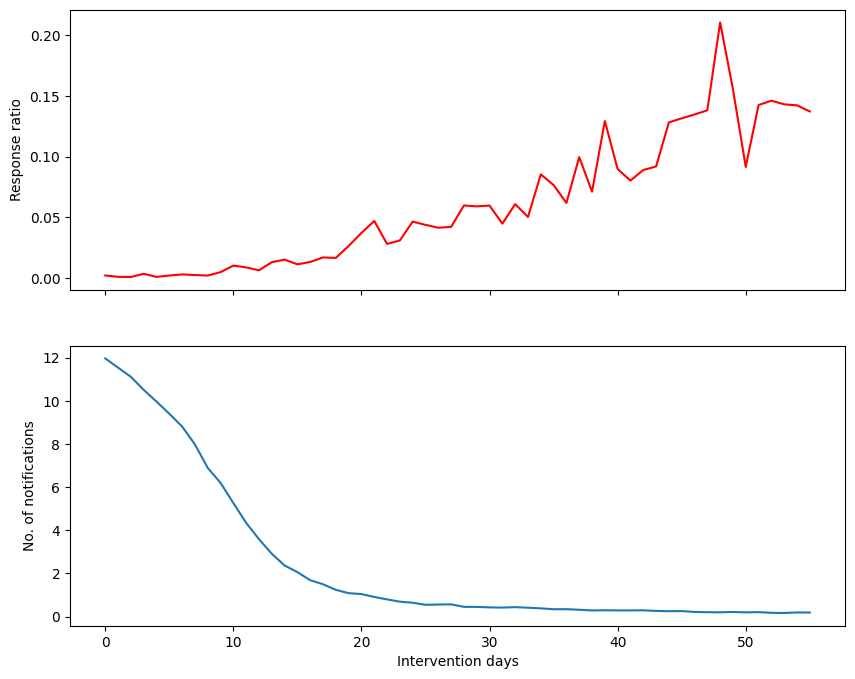

CPU times: user 58min 3s, sys: 1.16 s, total: 58min 5s
Wall time: 9min 3s


In [26]:
%time _= intervention(ppo, runs, 'ppo', condition)

In [27]:
rr_ppo_list, not_ppo_list, fppo = get_rr_and_notification('ppo', runs, condition)

 283 out of 500 runs had no activity performed throughout the full intervention.


## Advantage Actor Critic

In [28]:
def a2c(env1):
    model = A2C("MlpPolicy", env1, verbose=0, n_steps=updated_every_day, device="cpu")
    model.learn(total_timesteps=eight_weeks)
    return env1

This figures include runs in which no prompt resulted in the activity being performed
240 out of 500 resulted in activity being performed 


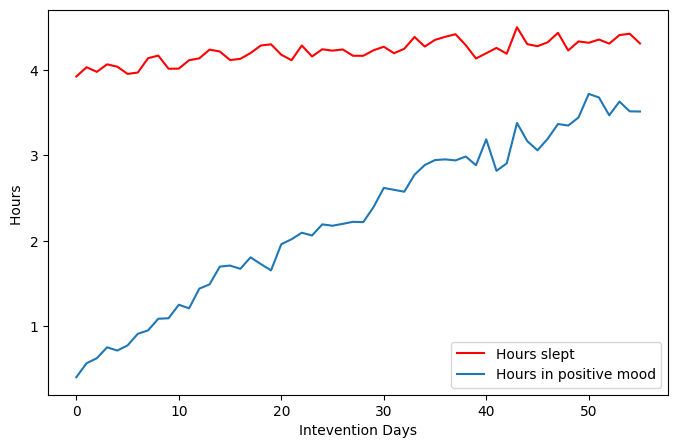

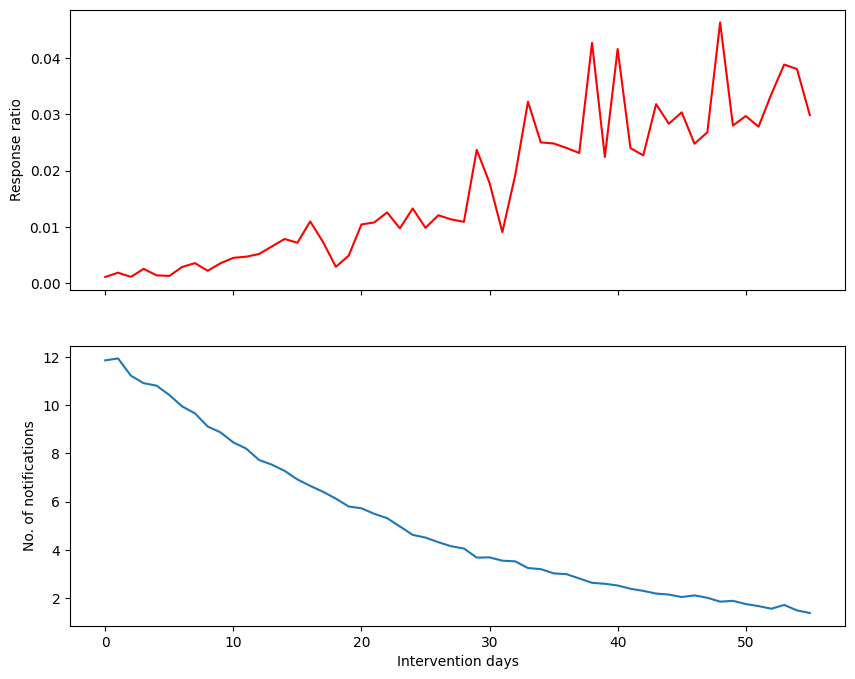

CPU times: user 20min 50s, sys: 506 ms, total: 20min 50s
Wall time: 4min 13s


In [29]:
%time _ = intervention(a2c, runs, 'a2c', condition)

In [30]:
rr_a2c_list, not_a2c_list, fppo = get_rr_and_notification('a2c', runs, condition)

 260 out of 500 runs had no activity performed throughout the full intervention.


## Comparison between prompt learning stategies

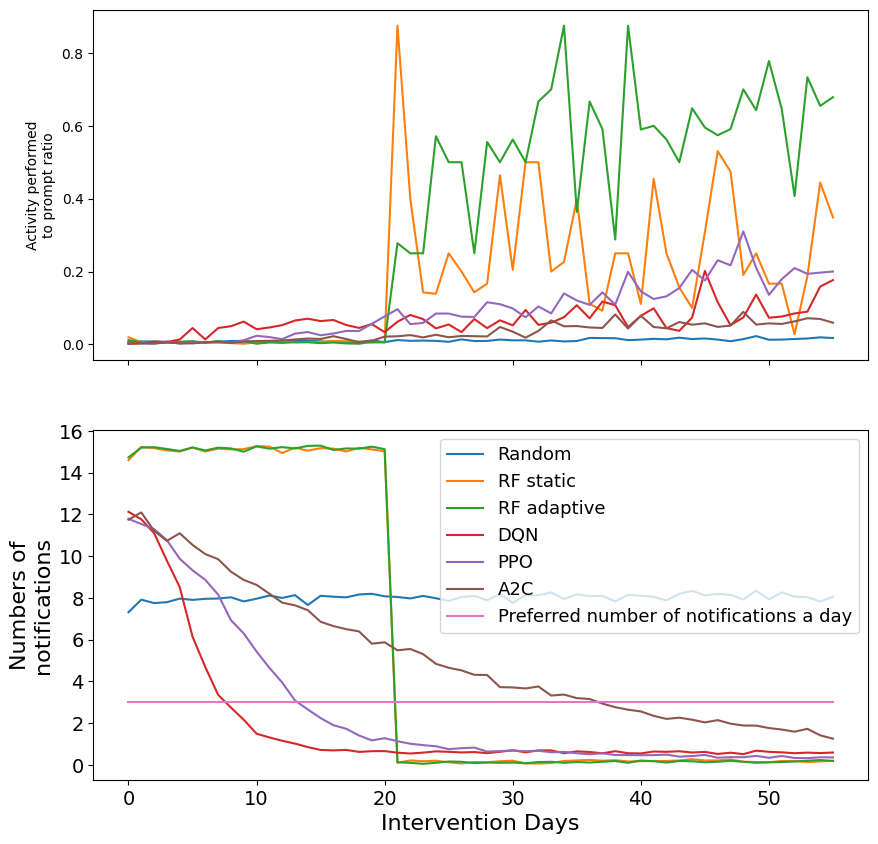

In [31]:
fig, (ax1,ax2) = plt.subplots(2, 1, sharex=True, sharey=False, figsize=(10,10))
ax1.plot(np.nanmean(rr_random_list, axis=0), label='Random')
ax1.plot(np.nanmean(rr_rf3_list, axis=0), label='RF static')
ax1.plot(np.nanmean(rr_rf3a_list, axis=0), label='RF adaptive')
ax1.plot(np.nanmean(rr_dqn_list, axis=0), label='DQN')
ax1.plot(np.nanmean(rr_ppo_list, axis=0), label='PPO')
ax1.plot(np.nanmean(rr_a2c_list, axis=0), label='A2C')


ax2.plot(np.nanmean(not_random_list, axis=0), label='Random')
ax2.plot(np.nanmean(not_rf3_list, axis=0), label='RF static')
ax2.plot(np.nanmean(not_rf3a_list, axis=0), label='RF adaptive')
ax2.plot(np.nanmean(not_dqn_list, axis=0), label='DQN')
ax2.plot(np.nanmean(not_ppo_list, axis=0), label='PPO')
ax2.plot(np.nanmean(not_a2c_list, axis=0), label='A2C')
ax2.plot(np.ones(len(np.mean(not_random_list, axis=0))) +2, label ='Preferred number of notifications a day')

ax2.set_xlabel('Intervention Days', fontsize=16)
ax2.set_ylabel('\n'.join(wrap('Numbers of notifications', 20)), fontsize=16)
ax1.set_ylabel('\n'.join(wrap('Activity performed to prompt ratio', 20)) )
# ax3.set_ylabel( '\n'.join(wrap('Hours slept', 20)) )
# plt.ylim(0, 0.95)
ax2.legend(fontsize=13)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Observations

Profile 2 responded very well to the Adaptive Random Forrest strategy at the cost of a high starting number of notification at the start of the experiment. This is not contrast to the DQN algorithm which quickly decreased the number of notifications however, performed only slightly better than random baseline in terms of activity performed to prompt ratio metric. In general, there seemed to be a strong trade-off between algorithms achieving better ratio results and requiring higher starting number of notifications, though some startegies are almost completly dominated by others such as the Static Random Forrest Approach which s the same notification number profile but was outperformed long-term by the adaptive version. PPO can be seen as a good middle-ground, outperforming A2C in terms of fewer notification and better ratio metric but is still achieves worse activity performed to response ratio when compared to the Adative Random Forrest. 

The reason behind the strong response to big stimuly such as the high number of notifications can also be related to this particular profile, such as the self-reinforcing pattern of breaking own records providing stronger motivation, meaning that once the patient is positively motivated, they are more likely to keep performing activity, even if it requires a lot of "nagging" at the start. This might also explain why the positive mood metric kept increasing as the number of days in the study rose, due to the positive feedback loop of the individual motivated by their own success.

In conclusion, for a profile such as Profile 2, where the individual is strongly motivated by breaking their own records and outperforming others, algorithms producing high number of notifications at the start such as Adaptive Random Forrest can be considered but other alternatives, such as PPO might also be a good idea, though in both cases getting the patient in a state of positive-feedback loop seems to be the best bet for their success.